In [ ]:
import xwrf
import xarray as xr
import numpy as np
import pandas as pd
import glob
import pickle
from netCDF4 import Dataset
from wrf import getvar #for RH
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Plot time series of 2m air temperature, UTCI hot spots, and UTCI cool spots at the highest-built point in the Paramatta suburb and a low-built point within a similar longitude (or two points in the central business distrcit CBD) for the LCZ, WSF-MB, and Geoscape cases - Figures 14 and S20

In [ ]:
#extract variables of interest

# Station information
awsnm = ['low built', 'high built']
#x_y = [[209, 208], [172, 166]]  #east: CBD, ...
x_y = [[183, 190], [190, 174]] #Paramatta high- low innerland

# File paths for different scenarios
paths = {
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/"
}

# Dictionary to store results for all scenarios
all_wrf_stations = {}

# Loop through each scenario
for scenario, path in paths.items():
    print(f"Processing {scenario}...")
    
    wrf_files = f"{path}wrfout_d02_2017-01*"
    files = sorted(glob.glob(wrf_files))
    
    if not files:
        print(f"Warning: No files found for {scenario} at {path}")
        continue
    
    # Initialize scenario-specific dictionary
    wrf_stations = {}
    
    # Get time information using xwrf (using first approach for time extraction)
    ds = xr.open_mfdataset(files, parallel=True, concat_dim="Time", combine="nested").xwrf.postprocess()
    sydney_time = ds["Time"] + np.timedelta64(10, "h")  # Convert UTC to Sydney time AEST
    wrf_stations['time'] = sydney_time
 
    # Initialize dictionaries for each variable and station
    temp = {}
    comf90 = {}
    comf10 = {}
    
    for name in awsnm:
        temp[name] = []
        comf10[name] = []
        comf90[name] = []
    
    # Process each file individually to extract point data
    for file in files:
        ds_single = xr.open_dataset(file)
        for i in range(len(awsnm)):
            # Extract data for each station
            temp[awsnm[i]].append(ds_single['T2'].isel(south_north=x_y[1][i], west_east=x_y[0][i]).item() - 273.15)
            comf90[awsnm[i]].append(ds_single['COMF_90'].isel(south_north=x_y[1][i], west_east=x_y[0][i]).item())
            comf10[awsnm[i]].append(ds_single['COMF_10'].isel(south_north=x_y[1][i], west_east=x_y[0][i]).item())
        ds_single.close()  # Close individual dataset to free memory
    
    # Store results for this scenario
    wrf_stations['T'] = temp
    wrf_stations['comf90'] = comf90
    wrf_stations['comf10'] = comf10
    
    # Add to main results dictionary
    all_wrf_stations[scenario] = wrf_stations
    
    print(f"Completed {scenario}: {len(files)} files processed")

# Close the multi-file dataset
ds.close()

print("All scenarios processed!")

# Access results like this:
# all_wrf_stations["LCZ"]["T"]["low built"] - Temperature time series for low built station in LCZ scenario
# all_wrf_stations["WSF3DMSB"]["comf90"]["high built"] - COMF90 time series for high built station in WSF3DMSB scenario
# all_wrf_stations["Geoscape"]["time"] - Time array for Geoscape scenario (all scenarios will have same time)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Processing LCZ...
Completed LCZ: 241 files processed
Processing WSF-MB...
Completed WSF-MB: 241 files processed
Processing Geoscape...
Completed Geoscape: 241 files processed
All scenarios processed!


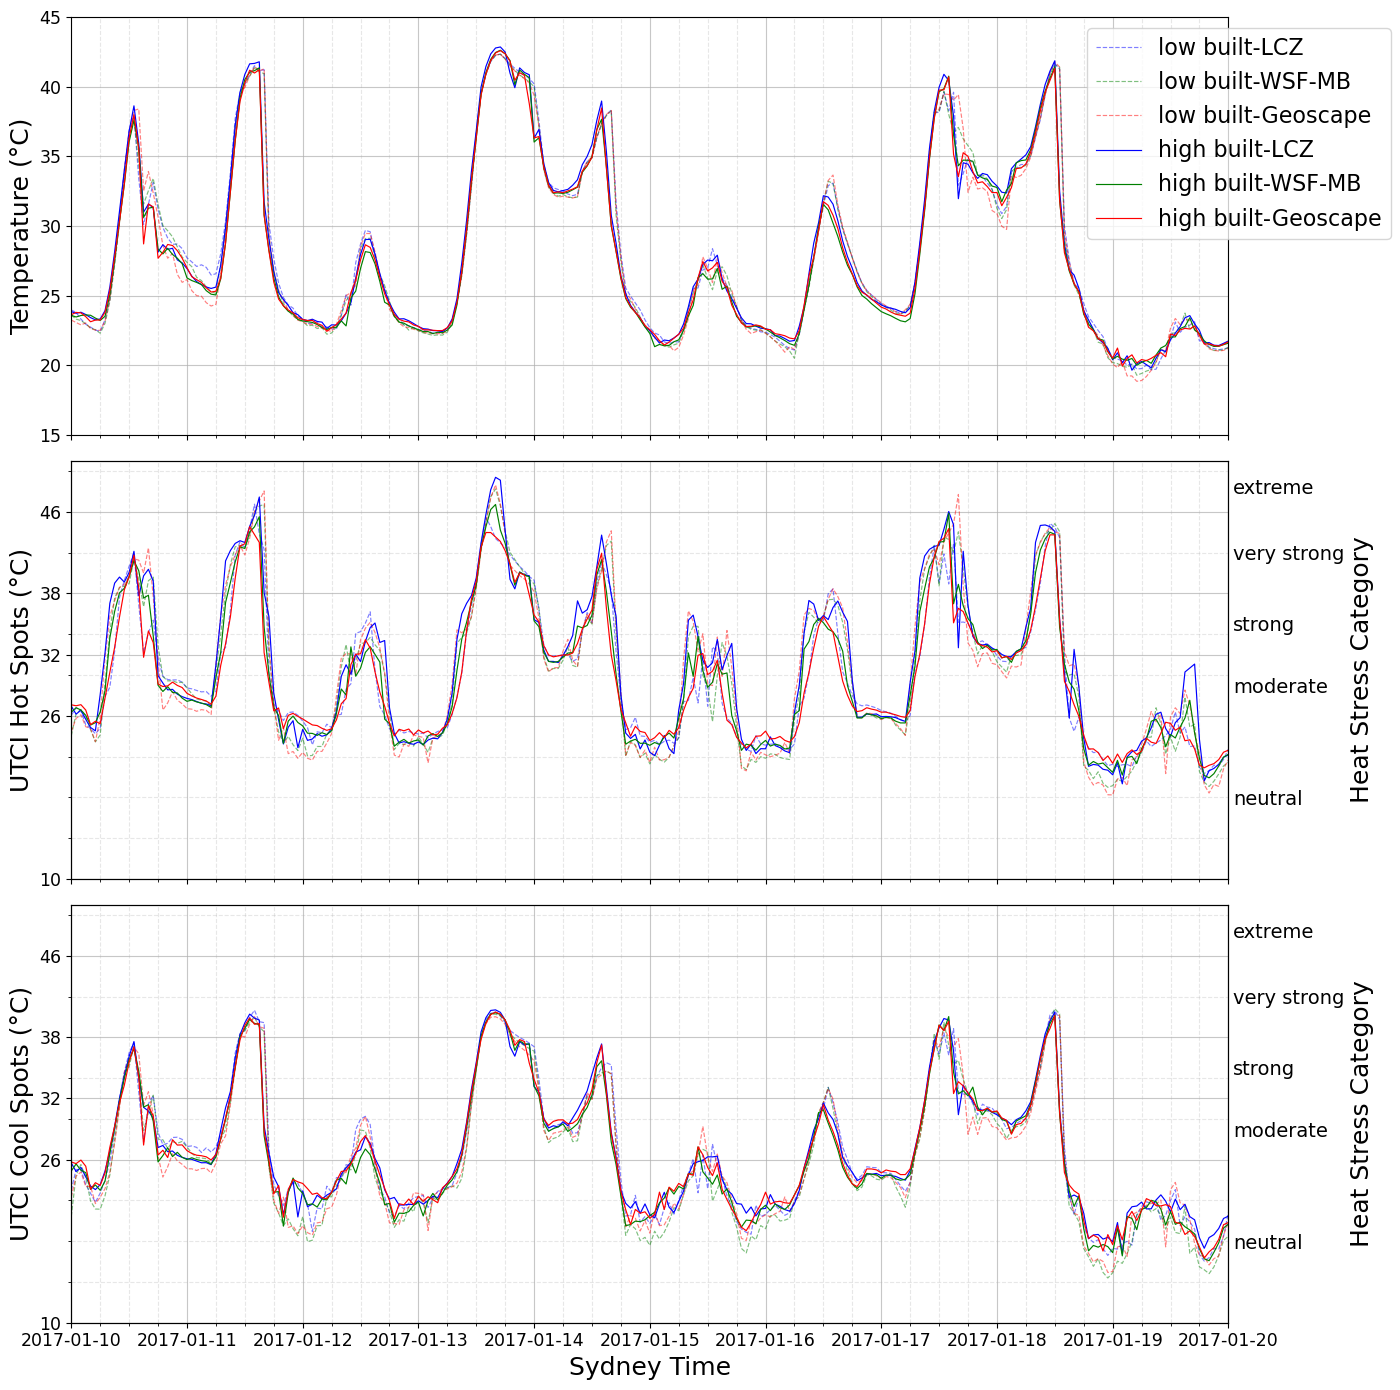

In [ ]:
# Multi-variable plotting for all scenarios

# Define line colors for scenarios and stations
line_colors = {
    'LCZ': 'blue',
    'WSF-MB': 'green',
    'Geoscape': 'red'
}

line_props = {
    'low built': {'line_style': 'dashed',
                  'alpha': 0.5},
    'high built': {'line_style': 'solid',
                   'alpha': 1}
}

# Station types
stations = ['low built', 'high built']
# Scenarios (note: WSF3DMSB is mapped to WSF3D for color coding)
scenarios = ['LCZ', 'WSF-MB', 'Geoscape']
scenario_color_map = {'LCZ': 'LCZ', 'WSF-MB': 'WSF-MB', 'Geoscape': 'Geoscape'}

# Define variables to plot with their properties
variables = {
    'T': {
        'ylabel': 'Temperature (°C)',
        'title': 'Time Series of Temperature - High-Built and Low-Built Points'
    },
    'comf90': {
        'ylabel': 'UTCI Hot Spots (°C)',
        'title': 'Time Series of UTCI Hot Spots - High-Built and Low-Built Points'
    },
    'comf10': {
        'ylabel': 'UTCI Cool Spots (°C)', 
        'title': 'Time Series of UTCI Cool Spots - High-Built and Low-Built Points'
    }
}

# UTCI heat stress categories
utci_ticks = [10, 26, 32, 38, 46]

# Category label positions (midpoints of ranges)
category_positions = [18, 29, 35, 42, 48.5]  # neutral, moderate, strong, very strong, extreme
category_labels = ['neutral', 'moderate', 'strong', 'very strong', 'extreme']

# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

# Plot each variable
for idx, (var_name, var_props) in enumerate(variables.items()):
    ax = axes[idx]
    
    # Plot each scenario and station combination
    for station in stations:
        for scenario in scenarios:
            # Plot the time series
            ax.plot(all_wrf_stations[scenario]['time'], 
                    all_wrf_stations[scenario][var_name][station], 
                    label=f'{station}-{scenario}', 
                    color=line_colors[scenario],
                    linestyle=line_props[station]['line_style'],
                    linewidth=0.85,
                    alpha=line_props[station]['alpha'])
    
    # Apply UTCI-specific formatting for UTCI subplots
    if var_name in ['comf90', 'comf10']:
        # Fix y-axis limits to 9-51
        ax.set_ylim(10, 51)
        
        # Set custom y-axis ticks for UTCI categories
        ax.set_yticks(utci_ticks)
        ax.set_yticklabels(utci_ticks)

        # Set minor ticks every 2 degrees for UTCI plots
        minor_ticks = range(10, 52, 4)  # 32, 34, 36, 38, 40, 42, 44, 46, 48, 50
        ax.set_yticks(minor_ticks, minor=True)
        
        # Create secondary y-axis for category labels
        ax2 = ax.twinx()
        ax2.set_ylim(10, 51)  # Match the main axis limits
        ax2.set_yticks(category_positions)
        ax2.set_yticklabels(category_labels, fontsize=14)
        ax2.set_ylabel('Heat Stress Category', fontsize=18)
        # Remove tick marks for cleaner appearance
        ax2.tick_params(length=0)
        
        # Turn off minor gridlines for UTCI plots since we have custom major gridlines
        ax.grid(True, which='major', linestyle='-', alpha=0.7)
        ax.grid(True, which='minor', linestyle='--', alpha=0.3)  # Minor gridlines every 2 degrees
        #ax.grid(False, which='minor')  # Turn off minor grid for cleaner look
    else:
        ax.set_ylim(15, 45)
        # Keep original gridlines for temperature subplot
        ax.grid(True, which='minor', linestyle='--', alpha=0.3)  # 6-hourly
        ax.grid(True, which='major', linestyle='-', alpha=0.7)   # daily
    
    # Set plot parameters for each subplot
    ax.set_xlim(pd.to_datetime("2017-01-10"), pd.to_datetime("2017-01-20"))
    ax.set_ylabel(var_props['ylabel'], fontsize=18)
    
    # Set x-axis ticks
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    ax.tick_params(axis='both', which='major', labelsize=12.5)
    
    # Add legend only to the first subplot to avoid repetition
    if idx == 0:
        ax.legend(bbox_to_anchor=(1.15, 1), loc='upper right', fontsize=16) #

# Set x-axis label only for the bottom subplot
axes[-1].set_xlabel("Sydney Time", fontsize=18)
#axes[-1].set_xticklabels(rotation=45)

# Adjust layout
plt.tight_layout()
plt.savefig("Fig14_Paramatta.png", dpi=300, bbox_inches='tight')
#plt.savefig("FigS20_CBD.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#calculate average UTCI exceedance for each point

# Initialize lists to store results
results = []

# Station names mapping
station_map = {
    'high built': 'high-built',
    'low built': 'low-built'
}

# Process each station (point)
for station in awsnm:
    point_name = station_map[station]
    
    # Process each experiment
    for experiment in ['LCZ', 'WSF-MB', 'Geoscape']:
        # Process both COMF_90 (hotspot) and COMF_10 (coolspot)
        for utci_type, utci_key in [('UTCI_90', 'comf90'), ('UTCI_10', 'comf10')]:
            # Get UTCI data
            utci_data = np.array(all_wrf_stations[experiment][utci_key][station])
            
            # Step 1: Calculate delta UTCI and count exceedance hours
            delta_utci = np.where(utci_data > 26, utci_data - 26, 0)
            exceedance_hours = np.sum(utci_data > 26)
            
            # Step 2: Sum of all delta UTCI values
            sum_delta_utci = np.sum(delta_utci)
            
            # Step 3: Calculate average delta UTCI (sum/H)
            if exceedance_hours > 0:
                avg_delta_utci = sum_delta_utci / exceedance_hours
            else:
                avg_delta_utci = 0  # or np.nan if you prefer
            
            # Store results
            results.append({
                'point': point_name,
                'experiment': experiment,
                'UTCI_type': utci_type,
                'H': exceedance_hours,
                'sum(delta UTCI)': sum_delta_utci,
                'sum(delta UTCI)/H': avg_delta_utci
            })

# Create DataFrame
df_results = pd.DataFrame(results)

# Create sorting keys
sort_map = {
    'high-built': 0, 'low-built': 1,
    'UTCI_90': 0, 'UTCI_10': 1,
    'LCZ': 0, 'WSF-MB': 1, 'Geoscape': 2
}

# Reorder to ensure high-built comes first, then low-built, and maintain experiment order
df_results = df_results.sort_values(
    by=['point', 'UTCI_type', 'experiment'], 
    key=lambda x: x.map(sort_map)
)
df_results = df_results.reset_index(drop=True)

# Display the results
print("\nUTCI Analysis Results (COMF_90 and COMF_10):")
print("=" * 100)
print(df_results.to_string(index=False))

# Save to CSV
output_filename = 'utci_analysis_results.csv'
df_results.to_csv(output_filename, index=False)
print(f"\nResults saved to: {output_filename}")

# Optional: Print summary statistics
print("\n" + "=" * 100)
print("Summary Statistics:")
print("=" * 100)
for point in ['high-built', 'low-built']:
    print(f"\n{point.upper()}:")
    for utci_type in ['UTCI_90', 'UTCI_10']:
        print(f"  {utci_type}:")
        point_data = df_results[(df_results['point'] == point) & 
                                (df_results['UTCI_type'] == utci_type)]
        for _, row in point_data.iterrows():
            print(f"    {row['experiment']:10s}: H={row['H']:3.0f} hrs, "
                  f"sum(ΔT)={row['sum(delta UTCI)']:7.2f}, "
                  f"avg(ΔT)={row['sum(delta UTCI)/H']:5.2f}")


UTCI Analysis Results (COMF_90 and COMF_10):
     point experiment UTCI_type   H  sum(delta UTCI)  sum(delta UTCI)/H
high-built        LCZ   UTCI_90 157      1415.619221           9.016683
high-built     WSF-MB   UTCI_90 151      1187.458750           7.863965
high-built   Geoscape   UTCI_90 153      1080.416500           7.061546
high-built        LCZ   UTCI_10 110       674.076170           6.127965
high-built     WSF-MB   UTCI_10 103       631.389626           6.129996
high-built   Geoscape   UTCI_10 108       648.383326           6.003549
 low-built        LCZ   UTCI_90 153      1153.897652           7.541815
 low-built     WSF-MB   UTCI_90 148      1333.428885           9.009655
 low-built   Geoscape   UTCI_90 154      1375.697727           8.933102
 low-built        LCZ   UTCI_10 114       716.001740           6.280717
 low-built     WSF-MB   UTCI_10 108       664.358454           6.151467
 low-built   Geoscape   UTCI_10 102       652.771221           6.399718

Results saved to: